### Load packages

In [141]:
import pandas as pd
import os
import textwrap
import numpy as np

# for figures
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from pandas.plotting import scatter_matrix

### Set project parameters for this run

In [142]:
# Project parameters

data_directory = r"..\data\merged_csvs"

algae_file = "algae_merged"
algae_path = os.path.join(data_directory, algae_file + ".csv")
print(algae_path)

..\data\merged_csvs\algae_merged.csv


### Load algae bloom data

In [143]:
# Load algae bloom data file

algae_raw_df = pd.read_csv(algae_path)

In [144]:
algae_raw_df.iloc[:5, :]
# vct_raw_df.iloc[:10, 10:25]
# vct_raw_df.iloc[:10, 10:25]

,vct_region,vct_report_date,vct_day_of_year,vct_latitude,vct_longitude,vct_water_temp_7days,vct_water_surface_7days,vct_target_bloom_intensity_7days,vct_anabaena_7days,vct_aphanizomenon_7days,...,noaa_wind_direction_5_min,noaa_air_temp_mean,dec_total nitrogen,dec_total phosphorus,dec_dissolved phosphorus,dec_chlorophyll-a,dec_secchi depth,dec_temperature,vct_target_bloom,vct_target_bloom_intensity
0,Main Lake Central,2014-09-30,273,44.484736,-73.288936,68.240,1.516667,1.550000,0.0,0.0,...,211.428571,15.228571,0.340,12.5,5.00,3.830,5.40,NaN,0,1.000
1,Main Lake Central,2014-10-02,275,44.484736,-73.288936,68.240,1.220000,1.550000,1.0,0.0,...,233.571429,15.328571,0.340,12.5,5.00,3.830,5.40,NaN,1,3.000
2,Main Lake Central,2015-06-14,165,44.484736,-73.288936,70.175,1.125000,1.821429,1.0,0.0,...,254.285714,16.521429,0.400,69.6,13.00,2.300,5.00,12.0,0,1.125
3,Main Lake Central,2015-06-15,166,44.484736,-73.288936,68.090,1.200000,1.696429,1.0,0.0,...,250.000000,16.992857,0.400,69.6,13.00,2.300,5.00,12.0,0,1.000
4,Main Lake Central,2015-06-16,167,44.484736,-73.288936,65.690,1.400000,1.553571,1.0,0.0,...,252.142857,17.557143,0.405,39.7,9.65,1.815,4.05,14.2,0,1.000


In [145]:
print(len(algae_raw_df.columns))
algae_raw_df.columns

52


Index(['vct_region', 'vct_report_date', 'vct_day_of_year', 'vct_latitude',
       'vct_longitude', 'vct_water_temp_7days', 'vct_water_surface_7days',
       'vct_target_bloom_intensity_7days', 'vct_anabaena_7days',
       'vct_aphanizomenon_7days', 'vct_microcystin_7days',
       'vct_oscillatoria_7days', 'vct_target_bloom_7days',
       'vct_water_temp_14days', 'vct_water_surface_14days',
       'vct_target_bloom_intensity_14days', 'vct_anabaena_14days',
       'vct_aphanizomenon_14days', 'vct_microcystin_14days',
       'vct_oscillatoria_14days', 'vct_target_bloom_14days',
       'usgs_water_temp_max_7days', 'usgs_water_temp_min_7days',
       'usgs_water_temp_mean_7days', 'usgs_conductivity_max_7days',
       'usgs_conductivity_min_7days', 'usgs_conductivity_mean_7days',
       'usgs_water_temp_max_14days', 'usgs_water_temp_min_14days',
       'usgs_water_temp_mean_14days', 'usgs_conductivity_max_14days',
       'usgs_conductivity_min_14days', 'usgs_conductivity_mean_14days',
      

In [146]:
# Convert number columns to floats and integers as appropriate

algae_numcols_df = algae_raw_df.copy()

date_cols = ["vct_report_date"]

string_cols = ["vct_region"]

integer_cols = [
    "vct_anabaena_7days",
    "vct_aphanizomenon_7days",
    "vct_microcystin_7days",
    "vct_oscillatoria_7days",
    "vct_anabaena_14days",
    "vct_aphanizomenon_14days",
    "vct_microcystin_14days",
    "vct_oscillatoria_14days",
    "vct_target_bloom",
    "vct_target_bloom_7days",
    "vct_target_bloom_14days",
    "vct_day_of_year"
]

# Format date columns
algae_numcols_df[date_cols] = (
    algae_numcols_df[date_cols]
    .apply(pd.to_datetime, errors="coerce")
)

# Format string columns
algae_numcols_df[string_cols] = algae_numcols_df[string_cols].astype("string")

# Format integer columns (nullable)
algae_numcols_df[integer_cols] = (
    algae_numcols_df[integer_cols]
        .apply(pd.to_numeric, errors="coerce")
        .astype("Int64")
)

# Format all remaining columns as floats
float_cols = algae_numcols_df.columns.difference(string_cols + integer_cols + date_cols)

algae_numcols_df[float_cols] = (
    algae_numcols_df[float_cols]
        .apply(pd.to_numeric, errors="coerce")
        .astype(float)
)

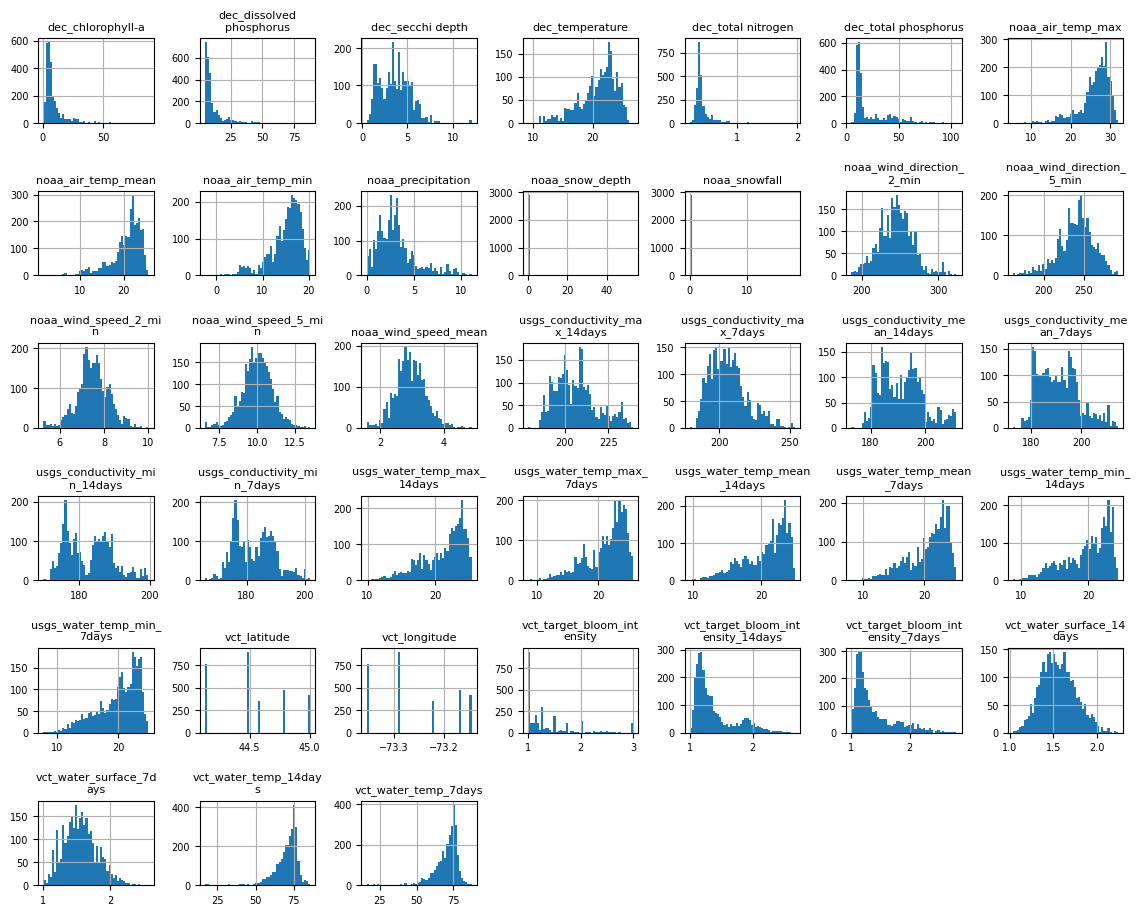

In [147]:
# Plot histograms of the numerical columns in the data

use_log_values = False

# histo_cols = ["vct_water_temp_trailing", "usgs_water_temp_max_trailing", "usgs_water_temp_min_trailing", "usgs_water_temp_mean_trailing", 
#               "usgs_conductivity_max_trailing", "usgs_conductivity_min_trailing", "usgs_conductivity_mean_trailing",
#               "noaa_PRCP", "noaa_TMIN", "noaa_TMAX", "noaa_AWND", "noaa_WDF2", "noaa_WSF2",
#               "noaa_WSF5", "noaa_WDF5", "noaa_TAVG", "dec_total nitrogen", "dec_total phosphorus", "dec_dissolved phosphorus",
#               "dec_chlorophyll-a", "dec_secchi depth", "dec_temperature"]

plot_df =  algae_numcols_df[float_cols].apply(pd.to_numeric, errors="coerce")

# Compute logs if needed
if use_log_values:
    safe_plot_df = plot_df.where(plot_df > -1)
    safe_plot_df = np.log10(safe_plot_df + 1)
else:
    safe_plot_df = plot_df.copy()

# drop columns that are all nulls or NaN values
safe_plot_df = safe_plot_df.dropna(axis=1, how="all")

axes = safe_plot_df.hist(bins=50, figsize=(14, 11), layout=(6, 7))

for ax in axes.flatten():
    title = ax.get_title()
    wrapped_title = "\n".join(textwrap.wrap(title, width=20))
    ax.set_title(wrapped_title, fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
    ax.tick_params(axis="x", labelsize=7)

plt.subplots_adjust(hspace=0.8, wspace=0.4)

plt.show()


In [148]:
algae_numcols_df.columns

Index(['vct_region', 'vct_report_date', 'vct_day_of_year', 'vct_latitude',
       'vct_longitude', 'vct_water_temp_7days', 'vct_water_surface_7days',
       'vct_target_bloom_intensity_7days', 'vct_anabaena_7days',
       'vct_aphanizomenon_7days', 'vct_microcystin_7days',
       'vct_oscillatoria_7days', 'vct_target_bloom_7days',
       'vct_water_temp_14days', 'vct_water_surface_14days',
       'vct_target_bloom_intensity_14days', 'vct_anabaena_14days',
       'vct_aphanizomenon_14days', 'vct_microcystin_14days',
       'vct_oscillatoria_14days', 'vct_target_bloom_14days',
       'usgs_water_temp_max_7days', 'usgs_water_temp_min_7days',
       'usgs_water_temp_mean_7days', 'usgs_conductivity_max_7days',
       'usgs_conductivity_min_7days', 'usgs_conductivity_mean_7days',
       'usgs_water_temp_max_14days', 'usgs_water_temp_min_14days',
       'usgs_water_temp_mean_14days', 'usgs_conductivity_max_14days',
       'usgs_conductivity_min_14days', 'usgs_conductivity_mean_14days',
      

In [149]:
# Find counts for all the categorical columns

cat_cols = ["vct_region", 
            "vct_anabaena_7days",
            "vct_aphanizomenon_7days",
            "vct_microcystin_7days",
            "vct_oscillatoria_7days",
            "vct_target_bloom",
]

for col in cat_cols:
    print(algae_numcols_df[col].value_counts(), "\n")


vct_region
Main Lake Central    897
Main Lake South      767
St. Albans Bay       477
Missisquoi Bay       424
Malletts Bay         354
Name: count, dtype: Int64 

vct_anabaena_7days
0    1562
1    1357
Name: count, dtype: Int64 

vct_aphanizomenon_7days
1    1490
0    1429
Name: count, dtype: Int64 

vct_microcystin_7days
0    1899
1    1020
Name: count, dtype: Int64 

vct_oscillatoria_7days
0    2650
1     269
Name: count, dtype: Int64 

vct_target_bloom
0    2210
1     709
Name: count, dtype: Int64 



In [150]:
# Format the data for time plots

algae_plots_df = algae_numcols_df.copy()

algae_plots_df["vct_report_date"] = pd.to_datetime(algae_plots_df["vct_report_date"])
algae_plots_df["year"] = algae_plots_df["vct_report_date"].dt.year

algae_plots_df = algae_plots_df[algae_plots_df["vct_report_date"].dt.year != 2014]

print(len(algae_plots_df))

algae_plots_df[["year", "vct_region", "vct_report_date"]].head()

2914


,year,vct_region,vct_report_date
2,2015,Main Lake Central,2015-06-14
3,2015,Main Lake Central,2015-06-15
4,2015,Main Lake Central,2015-06-16
5,2015,Main Lake Central,2015-06-17
6,2015,Main Lake Central,2015-06-18


In [151]:

# Count records per date per year
date_counts = (
    algae_plots_df
    .groupby(["year", "vct_region", "vct_report_date"])
    .size()
    .reset_index(name="count")
)

In [152]:
date_counts

,year,vct_region,vct_report_date,count
0,2015,Main Lake Central,2015-06-14,1
1,2015,Main Lake Central,2015-06-15,1
2,2015,Main Lake Central,2015-06-16,1
3,2015,Main Lake Central,2015-06-17,1
4,2015,Main Lake Central,2015-06-18,1
...,...,...,...,...
2909,2022,St. Albans Bay,2022-10-05,1
2910,2022,St. Albans Bay,2022-10-06,1
2911,2022,St. Albans Bay,2022-10-11,1
2912,2022,St. Albans Bay,2022-10-13,1


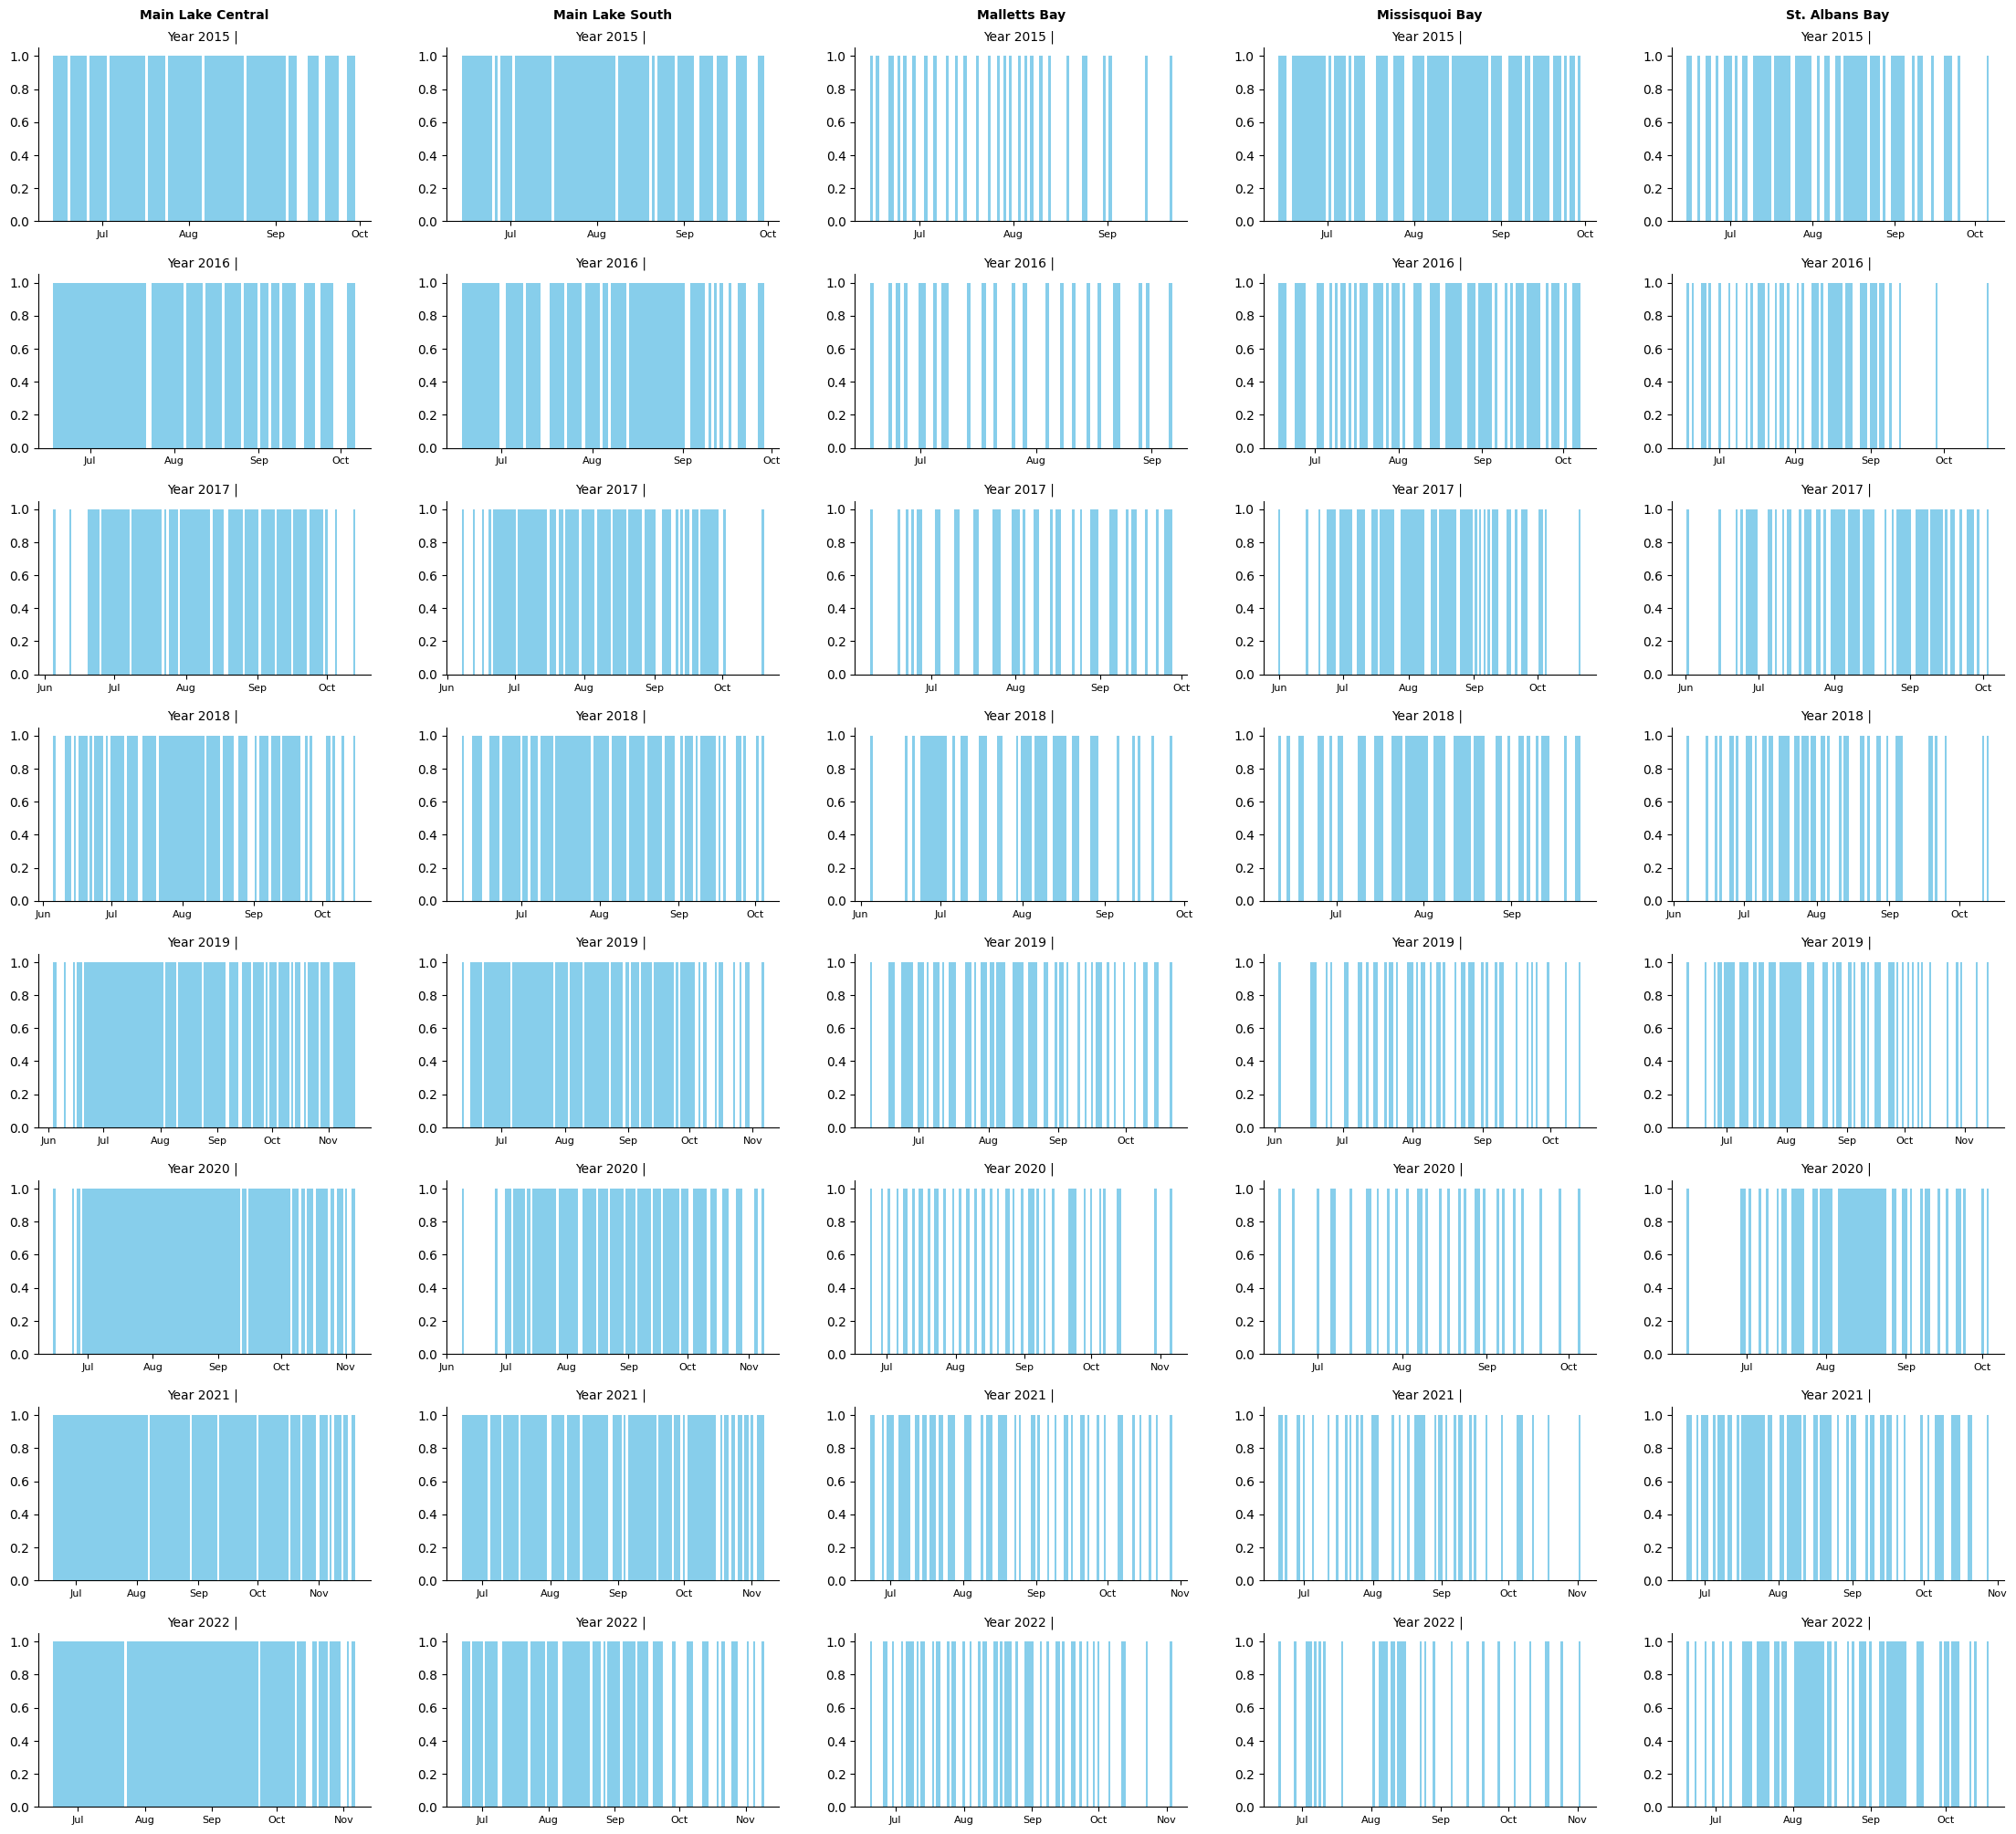

In [153]:
# Time plot - bar graphs per year

def barplot_datetime(data, **kwargs):
    ax = plt.gca()
    ax.bar(
        data["vct_report_date"],
        data["count"],
        color="skyblue",
        # edgecolor="black",
        width=1
    )

g = sns.FacetGrid(
    date_counts,
    row="year",
    col="vct_region",
    height=2.5,
    aspect=1.8,
    sharex=False,
    sharey=False
)

g.map_dataframe(barplot_datetime)

# Remove column names from subplot titles
g.set_titles(row_template="Year {row_name}", col_template="")

# Add region names at top of each column
regions = date_counts["vct_region"].sort_values().unique()
nrows, ncols = g.axes.shape
for col_idx, region in enumerate(regions):
    ax_top = g.axes[0, col_idx]
    ax_top.annotate(
        region,
        xy=(0.5, 1.15),
        xycoords="axes fraction",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Format x-axis
for ax in g.axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")


In [154]:
# Compute correlation coefficients for every number variable

# corr_cols = ["vct_water_temp_trailing", "usgs_water_temp_max_trailing", "usgs_water_temp_min_trailing", "usgs_water_temp_mean_trailing", 
#               "usgs_conductivity_max_trailing", "usgs_conductivity_min_trailing", "usgs_conductivity_mean_trailing",
#               "noaa_PRCP", "noaa_TMIN", "noaa_TMAX", "noaa_AWND", "noaa_WDF2", "noaa_WSF2",
#               "noaa_WSF5", "noaa_WDF5", "noaa_TAVG", "dec_total nitrogen", "dec_total phosphorus", "dec_dissolved phosphorus",
#               "dec_chlorophyll-a", "dec_secchi depth", "dec_temperature"]


corr_matrix = algae_plots_df[float_cols].corr()

for corr_col in float_cols:
    print(corr_matrix[corr_col].sort_values(ascending=False).round(2), "\n")


dec_chlorophyll-a                    1.00
dec_total phosphorus                 0.67
vct_target_bloom_intensity_14days    0.64
vct_target_bloom_intensity_7days     0.60
dec_total nitrogen                   0.50
vct_longitude                        0.44
vct_latitude                         0.43
vct_target_bloom_intensity           0.42
dec_dissolved phosphorus             0.33
dec_temperature                      0.19
usgs_water_temp_min_14days           0.16
usgs_water_temp_mean_14days          0.15
usgs_water_temp_max_14days           0.13
usgs_water_temp_min_7days            0.13
usgs_water_temp_mean_7days           0.11
usgs_water_temp_max_7days            0.10
vct_water_temp_14days                0.08
vct_water_temp_7days                 0.03
noaa_wind_direction_2_min            0.02
noaa_wind_direction_5_min            0.01
noaa_snow_depth                      0.01
noaa_snowfall                        0.01
usgs_conductivity_min_14days         0.01
usgs_conductivity_min_7days       

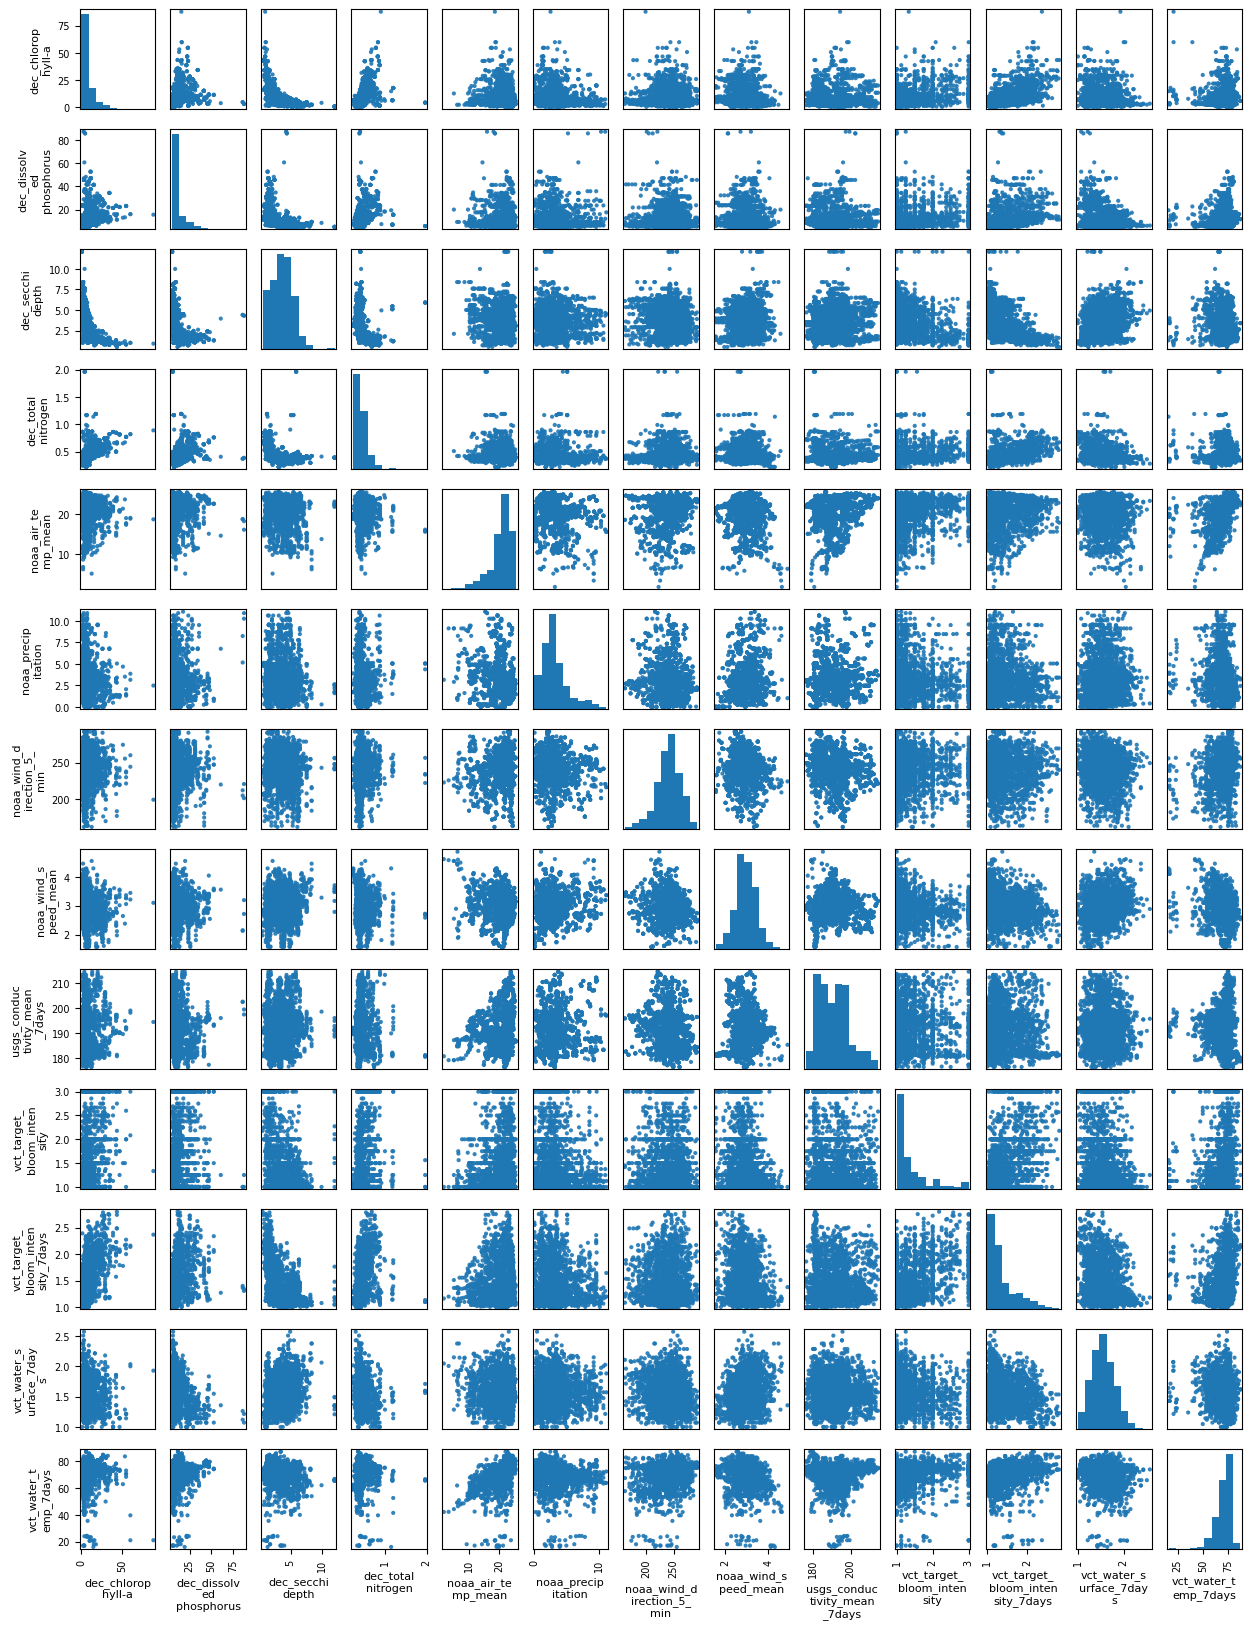

In [155]:
# Calculate scatterplots for every number variable pair

use_log_values = False

scatter_cols = ['dec_chlorophyll-a', 'dec_dissolved phosphorus', 'dec_secchi depth',
       'dec_total nitrogen', 
       'noaa_air_temp_mean',
       'noaa_precipitation',
       'noaa_wind_direction_5_min',
       'noaa_wind_speed_mean',
       'usgs_conductivity_mean_7days',
       'vct_target_bloom_intensity',
       'vct_target_bloom_intensity_7days',
       'vct_water_surface_7days',
       'vct_water_temp_7days']

plot_df = algae_plots_df[scatter_cols].apply(pd.to_numeric, errors="coerce")

# Compute logs if needed
if use_log_values:
    safe_plot_df = plot_df.where(plot_df > -1)
    safe_plot_df = np.log10(safe_plot_df + 1)
else:
    safe_plot_df = plot_df.copy()
    
axes = scatter_matrix(safe_plot_df[scatter_cols], figsize=(15, 20), alpha=0.9)

for ax in axes.flatten():
    # Wrap x-label
    xlabel = ax.get_xlabel()
    wrapped_xlabel = "\n".join(textwrap.wrap(xlabel, width=11))
    ax.set_xlabel(wrapped_xlabel, fontsize=8)

    # Wrap y-label
    ylabel = ax.get_ylabel()
    wrapped_ylabel = "\n".join(textwrap.wrap(ylabel, width=11))
    ax.set_ylabel(wrapped_ylabel, fontsize=8)

    # Optional: reduce tick label size
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

plt.subplots_adjust(hspace=0.2, wspace=0.2)
plt.show()

In [156]:
# Compute correlations for all number variables

# Compute correlation matrix
corr_matrix = algae_plots_df[float_cols].corr()

# Take the upper triangle to avoid duplicates and self-correlations
corr_matrix_upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Unstack to get pairs
corr_pairs = corr_matrix_upper.unstack().dropna()

In [157]:
# Sort by absolute correlation (descending)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# Show top pairs
print(corr_pairs_sorted.head(30))

usgs_water_temp_mean_14days       usgs_water_temp_max_14days           0.995505
usgs_water_temp_mean_7days        usgs_water_temp_max_7days            0.994960
usgs_water_temp_min_14days        usgs_water_temp_mean_14days          0.993340
usgs_water_temp_min_7days         usgs_water_temp_mean_7days           0.992263
noaa_air_temp_mean                noaa_air_temp_max                    0.988225
usgs_water_temp_mean_7days        usgs_water_temp_max_14days           0.981595
usgs_water_temp_min_7days         usgs_water_temp_mean_14days          0.979829
usgs_water_temp_min_14days        usgs_water_temp_max_14days           0.978692
usgs_water_temp_min_7days         usgs_water_temp_max_14days           0.978338
noaa_air_temp_min                 noaa_air_temp_mean                   0.977880
vct_longitude                     vct_latitude                         0.976593
usgs_water_temp_min_7days         usgs_water_temp_max_7days            0.976051
noaa_snowfall                     noaa_s

In [158]:
# Save the correlations to a csv

# Take upper triangle to avoid duplicates and self-correlations
corr_matrix = algae_plots_df[float_cols].corr()
corr_matrix_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = corr_matrix_upper.unstack().dropna()

# Sort by absolute correlation
corr_pairs_sorted = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# Convert to DataFrame
corr_df = corr_pairs_sorted.reset_index()
corr_df.columns = ["Variable 1", "Variable 2", "Correlation"]

# Optional: round correlations to 2 decimals
corr_df["Correlation"] = corr_df["Correlation"].round(2)

# Save to CSV
corr_df.to_csv(r"..\data\merged_csvs\numerical_feature_correlations.csv", index=False)

In [159]:
# Compute correlations of float columns with target_bloom_intensity

# Identify the target column
target_col = "vct_target_bloom_intensity"

# Make a list of float columns excluding the target itself
other_float_cols = [c for c in float_cols if c != target_col]

# Compute correlations of the target with all other float columns
target_corr = algae_plots_df[other_float_cols + [target_col]].corr()[target_col].loc[other_float_cols]

# Optional: sort by absolute correlation
target_corr_sorted = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)

# Convert to DataFrame
target_corr_df = target_corr_sorted.reset_index()
target_corr_df.columns = ["feature", "correlation"]

# Save to CSV
target_corr_df.to_csv(
    r"..\data\merged_csvs\numerical_feature_correlations_to_target.csv", 
    index=False
)

print(target_corr_df)

                              feature  correlation
0    vct_target_bloom_intensity_7days     0.545598
1   vct_target_bloom_intensity_14days     0.516823
2                dec_total phosphorus     0.482933
3                   dec_chlorophyll-a     0.415867
4                       vct_longitude     0.397202
5                        vct_latitude     0.375755
6                    dec_secchi depth    -0.365178
7            dec_dissolved phosphorus     0.304976
8                  dec_total nitrogen     0.265241
9                     dec_temperature     0.226782
10         usgs_water_temp_min_14days     0.191442
11        usgs_water_temp_mean_14days     0.188858
12         usgs_water_temp_max_14days     0.182698
13          usgs_water_temp_min_7days     0.177140
14         usgs_water_temp_mean_7days     0.171047
15          usgs_water_temp_max_7days     0.161730
16              noaa_wind_speed_2_min    -0.161038
17              noaa_wind_speed_5_min    -0.153276
18               noaa_wind_spee